24RB1074　半田悠人

## 課題：LLEの実装

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import LocallyLinearEmbedding


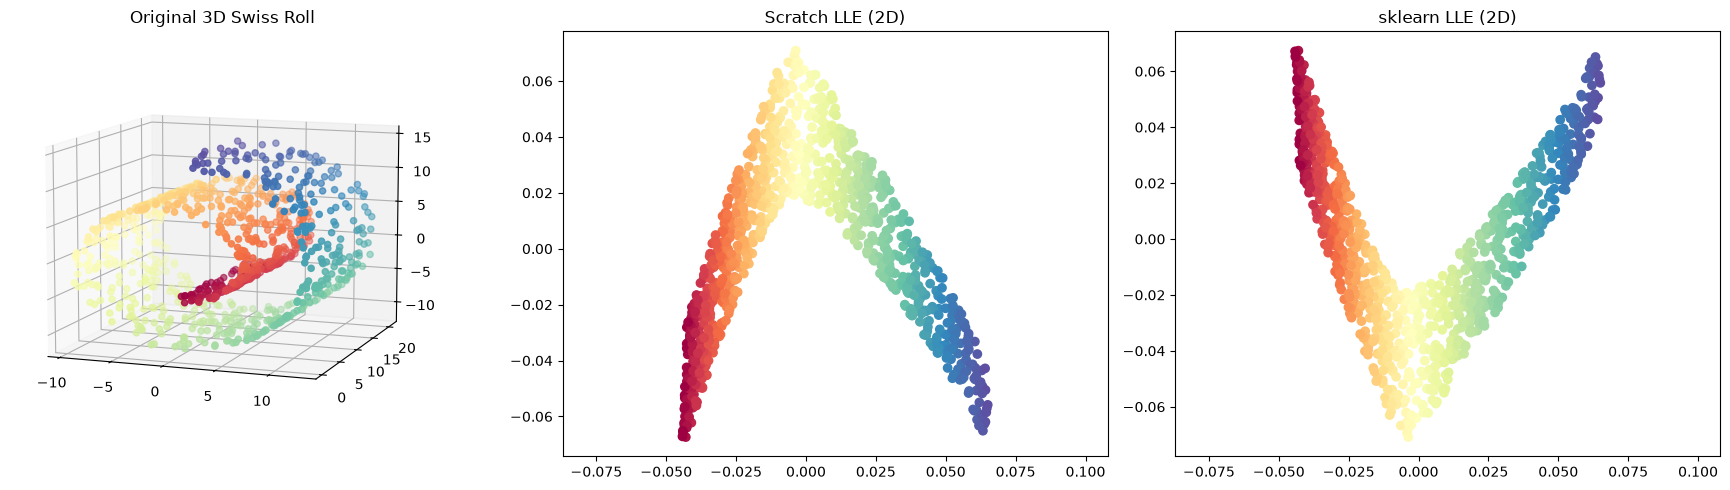

In [2]:

k = 10
X, t = make_swiss_roll(n_samples=1000, noise=0.05)

# 1.各点のk近傍を求める
nbrs = NearestNeighbors(n_neighbors=k+1)
nbrs.fit(X)
distances, indices = nbrs.kneighbors(X)
indices = indices[:, 1:]  

W = np.zeros((X.shape[0], X.shape[0]))

for i in range(X.shape[0]):
    # 2. 各点iについての局所グラム行列Cを計算
    C = np.zeros((k, k))
    for j in range(k):
        for l in range(k):
            dif_j = X[i] - X[indices[i, j]]
            dif_l = X[i] - X[indices[i, l]]
            C[j, l] = dif_j.T @ dif_l

    C += np.trace(C) * np.eye(k) * 1e-3
    C_inv = np.linalg.inv(C)
    
    one_vec = np.ones((k, 1))

    # 閉形式解wからWを構築
    w = C_inv @ one_vec / (one_vec.T @ C_inv @ one_vec)

    for j in range(k):
        W[i, indices[i, j]] = w[j, 0]

# 3. 固有値分解と2次元埋め込み
I = np.eye(X.shape[0])
M = (I - W).T @ (I - W)
eigenvalues, eigenvectors = np.linalg.eigh(M)
Y = eigenvectors[:, 1:3]


# 4,5. データのプロット
fig = plt.figure(figsize=(18, 5))

# 元の3次元データ
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral)
ax1.set_title("Original 3D Swiss Roll")
ax1.view_init(10, -70)

# 手動実装
ax2 = fig.add_subplot(132)
ax2.scatter(Y[:, 0], Y[:, 1], c=t, cmap=plt.cm.Spectral)
ax2.set_title("Scratch LLE (2D)")
ax2.axis('equal')


# sklearn実装
lle = LocallyLinearEmbedding(n_neighbors=k, n_components=2, method='standard')
Y_sklearn = lle.fit_transform(X)

ax3 = fig.add_subplot(133)
ax3.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], c=t, cmap=plt.cm.Spectral)
ax3.set_title("sklearn LLE (2D)")
ax3.axis('equal')

plt.tight_layout()
plt.show()



## 観察
* **手動実装LLE:** スイスロールが2次元平面上で重なることなく展開させれいる。色のグラデーションから、多様体上の位置関係が保持されていることが分かる。
* **sklearnと比較:** 手動実装と左右が反転しているが、相対的な広がりや構造は一致している。


## AI利用
`NearestNeighbors`の引数、戻り値、使い方などを質問した。Wの構築において、配列のインデックス整合や次元数確認にGeminiを利用した。